In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/1000img/1000movies.jpg
/kaggle/input/imdb-dataset-of-top-1000-movies-and-tv-shows/imdb_top_1000.csv


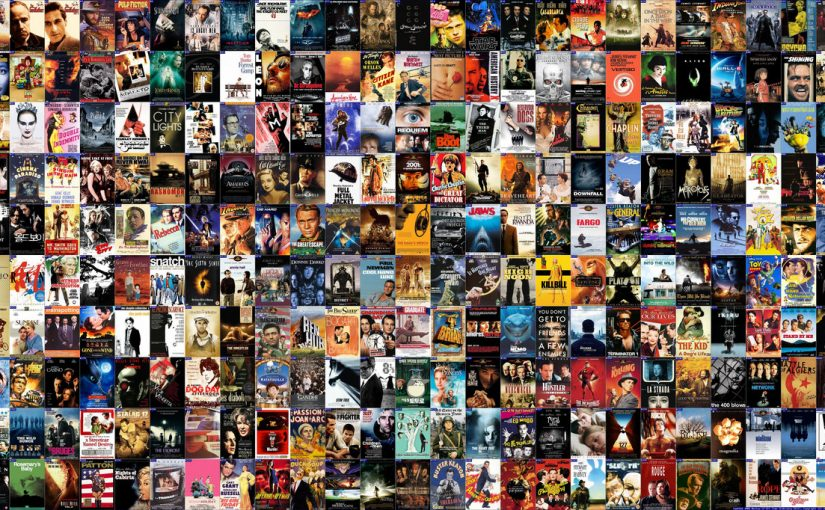

In [22]:
from IPython.display import Image, display
display(Image(filename="/kaggle/input/1000img/1000movies.jpg"))


In [19]:
df = pd.read_csv("/kaggle/input/imdb-dataset-of-top-1000-movies-and-tv-shows/imdb_top_1000.csv")
df.head()


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [3]:
import pandas as pd
import plotly.express as px


In [4]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("/kaggle/input/imdb-dataset-of-top-1000-movies-and-tv-shows/imdb_top_1000.csv")

# Convert numeric columns that are stored as strings
df["No_of_Votes"] = pd.to_numeric(df["No_of_Votes"], errors="coerce")
df["IMDB_Rating"] = pd.to_numeric(df["IMDB_Rating"], errors="coerce")

# Now create scatter plot
fig1 = px.scatter(
    df,
    x="No_of_Votes",
    y="IMDB_Rating",
    size="IMDB_Rating",
    color="Genre",
    hover_name="Series_Title",
    title="IMDB Rating vs Number of Votes"
)
fig1.show()


In [5]:
# Top 10 movies sorted by IMDB rating
top10 = df.nlargest(10, "IMDB_Rating")

fig2 = px.bar(
    top10,
    x="Series_Title",
    y="IMDB_Rating",
    color="IMDB_Rating",
    title="Top 10 Movies by IMDB Rating",
    text="IMDB_Rating"
)
fig2.update_layout(xaxis_tickangle=-45)
fig2.show()


In [6]:
fig3 = px.histogram(
    df,
    x="IMDB_Rating",
    nbins=20,
    title="Distribution of IMDB Ratings",
    color_discrete_sequence=["#1f77b4"]
)
fig3.show()


In [7]:
fig4 = px.box(
    df,
    x="Genre",
    y="IMDB_Rating",
    title="IMDB Ratings by Genre",
    points="all"  # shows all data points
)
fig4.update_layout(xaxis_tickangle=-45)
fig4.show()


In [23]:
import plotly.express as px

# Count movies per director
top_directors = df['Director'].value_counts().nlargest(10).reset_index()
top_directors.columns = ['Director', 'Movie Count']

# Create pie chart
fig_directors = px.pie(
    top_directors,
    names='Director',
    values='Movie Count',
    title='Top 10 Directors by Number of Movies',
    hole=0.3  # donut style
)

fig_directors.show()


In [8]:
# Convert Released_Year to numeric
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")

avg_rating = df.groupby("Released_Year", as_index=False)["IMDB_Rating"].mean()

fig5 = px.line(
    avg_rating,
    x="Released_Year",
    y="IMDB_Rating",
    title="Average IMDB Rating per Year"
)
fig5.show()


In [9]:
import plotly.express as px

# Select Top 10 movies
top10_movies = df.nlargest(10, "IMDB_Rating")[["Series_Title", "IMDB_Rating"]]

# Create pie chart
fig_pie_top10 = px.pie(
    top10_movies,
    names="Series_Title",
    values="IMDB_Rating",
    title="Top 10 Movies by IMDB Rating",)

fig_pie_top10.show()


In [11]:
import plotly.graph_objects as go

# Select top 20 by IMDB rating
top20 = df.nlargest(20, "IMDB_Rating")[["Series_Title", "Released_Year", "IMDB_Rating", "No_of_Votes", "Gross"]]

fig_table = go.Figure(data=[go.Table(
    header=dict(values=list(top20.columns),
                fill_color='lightblue',
                align='left'),
    cells=dict(values=[top20[col] for col in top20.columns],
               fill_color='lightyellow',
               align='left'))
])

fig_table.show()


In [12]:
fig_scatter = px.scatter(
    df,
    x="No_of_Votes",
    y="IMDB_Rating",
    size="IMDB_Rating",
    color="Genre",
    hover_name="Series_Title",
    title="IMDB Rating vs Number of Votes"
)
fig_scatter.show()


In [13]:
top_directors = df['Director'].value_counts().nlargest(10).reset_index()
top_directors.columns = ['Director', 'Count']

fig_bar = px.bar(
    top_directors,
    x="Director",
    y="Count",
    color="Count",
    title="Top 10 Directors by Number of Movies"
)
fig_bar.show()


In [14]:
fig_box = px.box(
    df,
    x="Genre",
    y="IMDB_Rating",
    points="all",
    title="IMDB Ratings by Genre"
)
fig_box.update_layout(xaxis_tickangle=-45)
fig_box.show()


In [15]:
# Clean Gross column
df["Gross"] = df["Gross"].replace(",", "", regex=True)
df["Gross"] = pd.to_numeric(df["Gross"], errors="coerce")

fig_gross = px.scatter(
    df,
    x="Gross",
    y="IMDB_Rating",
    size="No_of_Votes",
    color="Genre",
    hover_name="Series_Title",
    title="Gross Earnings vs IMDB Rating"
)
fig_gross.show()


In [16]:
cert_counts = df["Certificate"].value_counts().reset_index()
cert_counts.columns = ["Certificate", "Count"]

fig_pie = px.pie(
    cert_counts,
    names="Certificate",
    values="Count",
    title="Movies Distribution by Certificate",
    hole=0.3
)
fig_pie.show()


In [18]:
import plotly.graph_objects as go

# Calculate summary stats
total_movies = len(df)
avg_rating = df["IMDB_Rating"].mean()
highest_rated_movie = df.loc[df["IMDB_Rating"].idxmax(), "Series_Title"]
highest_rating = df["IMDB_Rating"].max()
most_votes_movie = df.loc[df["No_of_Votes"].idxmax(), "Series_Title"]
most_votes = df["No_of_Votes"].max()
top_genre = df["Genre"].value_counts().idxmax()
top_director = df["Director"].value_counts().idxmax()

# Create summary table
summary_data = [
    ["Total Movies", total_movies],
    ["Average IMDB Rating", round(avg_rating, 2)],
    ["Highest Rated Movie", f"{highest_rated_movie} ({highest_rating})"],
    ["Most Voted Movie", f"{most_votes_movie} ({most_votes:,} votes)"],
    ["Most Common Genre", top_genre],
    ["Top Director by Count", top_director]
]

fig_summary = go.Figure(data=[go.Table(
    header=dict(values=["Metric", "Value"],
                fill_color="lightblue",
                align="left"),
    cells=dict(values=[[row[0] for row in summary_data],
                       [row[1] for row in summary_data]],
               fill_color="lightyellow",
               align="left"))
])

fig_summary.update_layout(title="📊 Dataset Summary")
fig_summary.show()
